## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import *
from src.plots import *
from src.visualization import *
from src.neural_network import *
from src.improved_neural_network import *
from src.experiment import *
from src.utils import *

import torch
import torch.nn as nn
import torch.optim as optim
from src.pytorch_network import *

In [5]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

print("Forma de X_images:", X_images.shape)
print("Forma de y_images:", y_images.shape)
print("Número de clases únicas:", len(np.unique(y_images)))

Forma de X_images: (5000, 784)
Forma de y_images: (5000,)
Número de clases únicas: 49


1. Una visión clara de la distribución de clases para detectar posibles desbalances
2. Estadísticas sobre los valores de píxeles para entender las propiedades generales de las imágenes
3. Imágenes "promedio" de cada clase para visualizar sus características distintivas
4. Un análisis de complejidad por clase para ver cuáles pueden ser más difíciles de clasificar
5. Múltiples ejemplos de cada clase para comprender mejor la variabilidad dentro de cada categoría

In [6]:
# plot_class_examples(X_images, y_images, figsize=(10, 13), suptitle="Examples of each character class")
# visualize_samples(X_train, y_train, num_samples=5, num_classes=10, figsize=(8, 15))
# plot_class_distribution(y_images)
# analyze_image_statistics(X_images)
# plot_class_averages(X_images, y_images, num_classes=15)  # Mostrar las primeras 15 clases
# analyze_image_complexity(X_images, y_images)

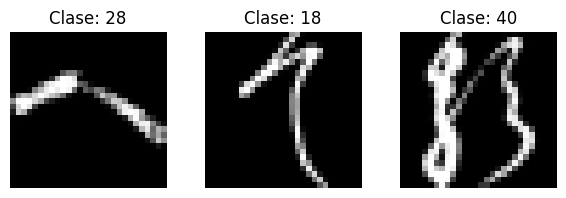

In [7]:
plt.figure(figsize=(6, 2))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = np.random.randint(0, len(X_images))
    img = X_images[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Clase: {y_images[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8 * 0.8, val_ratio=0.8 * 0.2, test_ratio=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_val: {X_val.shape}, y_val: {len(y_val)}")
print(f"X_test: {X_test.shape}, y_test: {len(y_test)}")
print(f"Rango de valores en X_train: [{X_train.min()}, {X_train.max()}]")

X_train: (3197, 784), y_train: 3197
X_val: (802, 784), y_val: 802
X_test: (1001, 784), y_test: 1001
Rango de valores en X_train: [0.0, 1.0]


### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos confunción de activación ReLU (en las capas ocultas) y activación softmax para la capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendiente estándar, utilizando como función de costo la cross-entropy. 
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasificación multi-clase con función de activación softmax para la capa de salida y función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión

Epoch: [=================================================>] 100% - train_loss: 0.6248 - train_acc: 0.8661 - val_loss: 1.7288 - val_acc: 0.5736

Training completed in 504.67 seconds
Best epoch: 4804
Final train loss: 0.6248, train accuracy: 0.8661
Final val loss: 1.7288, val accuracy: 0.5736
Best val loss: 1.7285, best val accuracy: 0.5736
Model successfully saved to modelos/model_M0.pkl


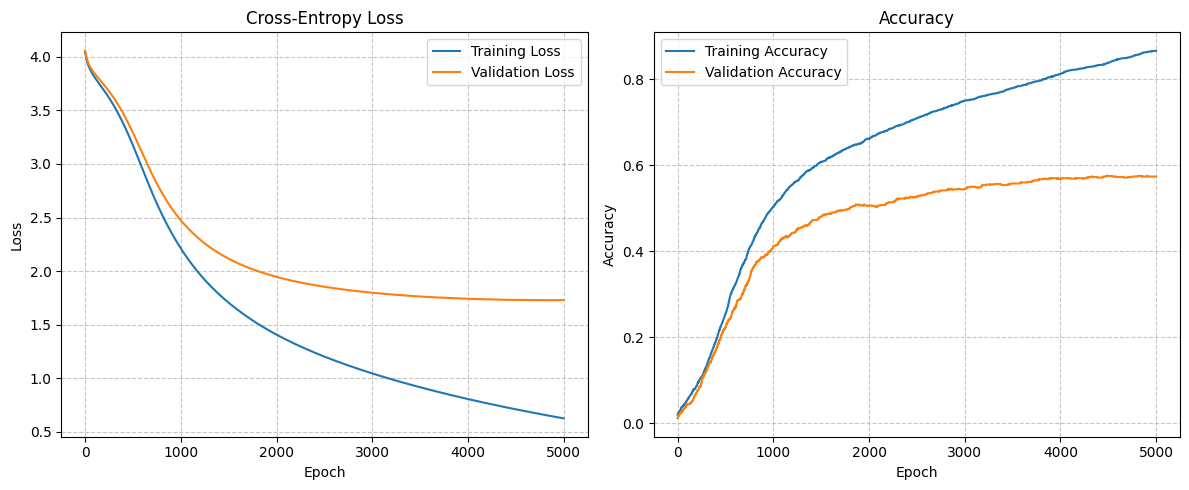

In [9]:
input_size = X_train.shape[1]
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=5000)
save_model(model_M0, "model_M0.pkl")

plot_learning_curves(history_M0)

In [10]:
train_pred = model_M0.forward(X_train)
val_pred = model_M0.forward(X_val)

train_loss = model_M0.cross_entropy_loss(y_train, train_pred)
val_loss = model_M0.cross_entropy_loss(y_val, val_pred)

train_accuracy = model_M0.accuracy(y_train, train_pred)
val_accuracy = model_M0.accuracy(y_val, val_pred)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")


Performance Metrics for Model M0:
Training Set - Accuracy: 0.8661, Cross-Entropy: 0.6248
Validation Set - Accuracy: 0.5736, Cross-Entropy: 1.7288


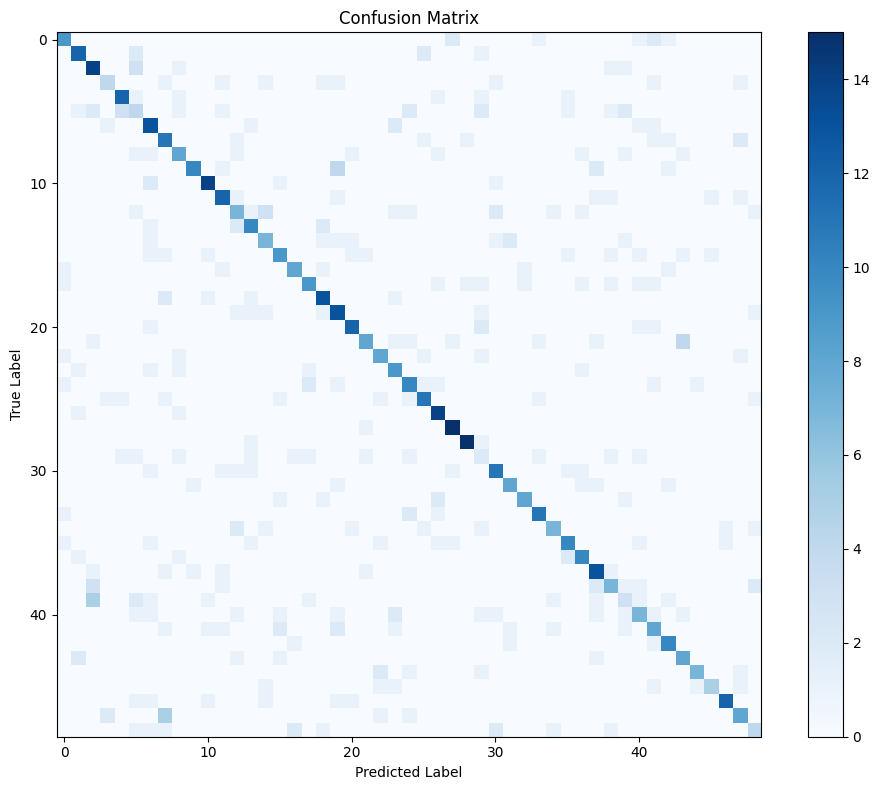

In [ ]:
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

### 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
- Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
    - Rate scheduling lineal (con saturación) y exponencial.
    - Mini-batch stochastic gradient descent.
    - Optimizador ADAM.
    - Regularización L2.
    - Regularización mediante early stopping.
    - OPCIONAL: Regularización mediante dropout.
    - OPCIONAL: batch normalization.
- Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y los hiperparámetros (cada uno de los items en la lista anterior tiene una serie de parámetros que podemos variar), y determinar la configuración que funcione mejor (menor error de validación).
Llamaremos a este modelo M1.

In [12]:
input_size = X_train.shape[1] 
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

In [13]:
experiments = [
    {
        'name': 'Baseline (SGD)',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    }, {
        'name': 'Linear Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'linear',
        'early_stopping_patience': None
    },{
        'name': 'Exponential Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'exponential',
        'early_stopping_patience': None
    },{
        'name': 'Mini-batch SGD',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'ADAM Optimizer',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'L2 Regularization',
        'learning_rate': 0.001,
        'l2_lambda': 0.001,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Early Stopping',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': 10  
    },{
        'name': 'Dropout',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.2,  
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Batch Normalization',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': True,  
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Combined Improvements',
        'learning_rate': 0.001,
        'l2_lambda': 0.0005,  
        'dropout_rate': 0.2,  
        'use_batch_norm': True,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': 'exponential', 
        'early_stopping_patience': 15 
    }
]


Running experiment: Baseline (SGD)
Epoch: [=================================================>] 100% - train_loss: 1.2644 - train_acc: 0.6935 - val_loss: 1.8312 - val_acc: 0.5349 - lr: 0.0100

Training completed in 239.00 seconds
Best epoch: 2000
Final train loss: 1.2644, train accuracy: 0.6935
Final val loss: 1.8312, val accuracy: 0.5349
Best val loss: 1.8312, best val accuracy: 0.5349

Results for Baseline (SGD):
Training time: 239.00 seconds
Final train loss: 1.2644, train accuracy: 0.6935
Final val loss: 1.8312, val accuracy: 0.5349

Running experiment: Linear Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 1.6270 - train_acc: 0.6128 - val_loss: 2.0439 - val_acc: 0.4888 - lr: 0.0050

Training completed in 239.18 seconds
Best epoch: 2000
Final train loss: 1.6270, train accuracy: 0.6128
Final val loss: 2.0439, val accuracy: 0.4888
Best val loss: 2.0439, best val accuracy: 0.4888

Results for Linear Rate Scheduling:
Training time: 239.18 

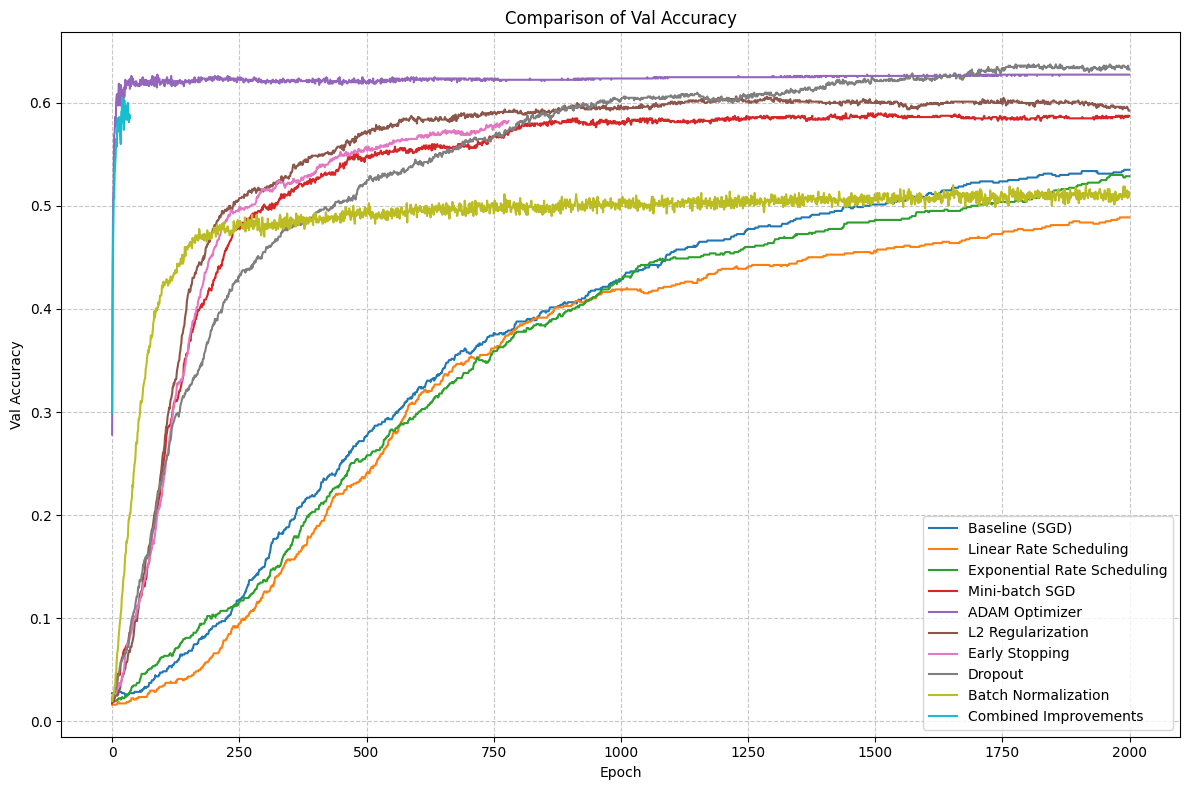

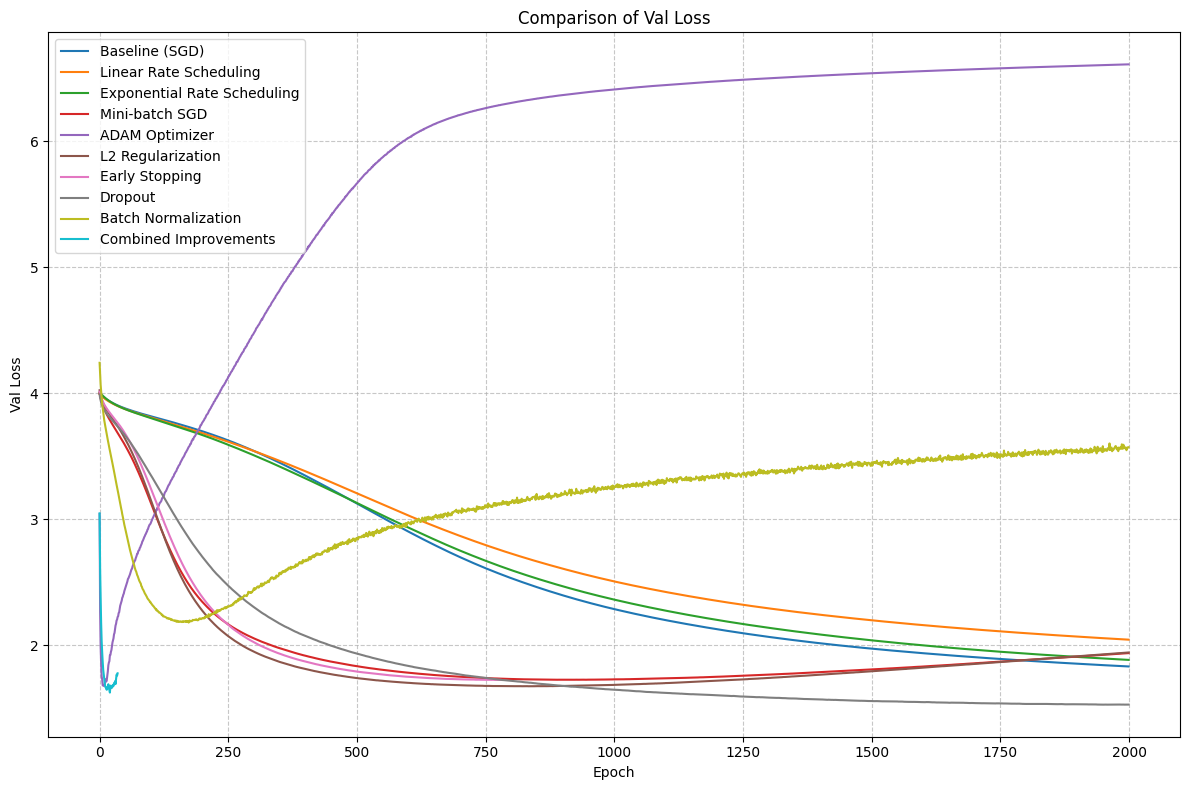

In [ ]:
results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, layer_sizes, experiments)

plot_experiment_results(results, metric='val_accuracy')
plot_experiment_results(results, metric='val_loss')

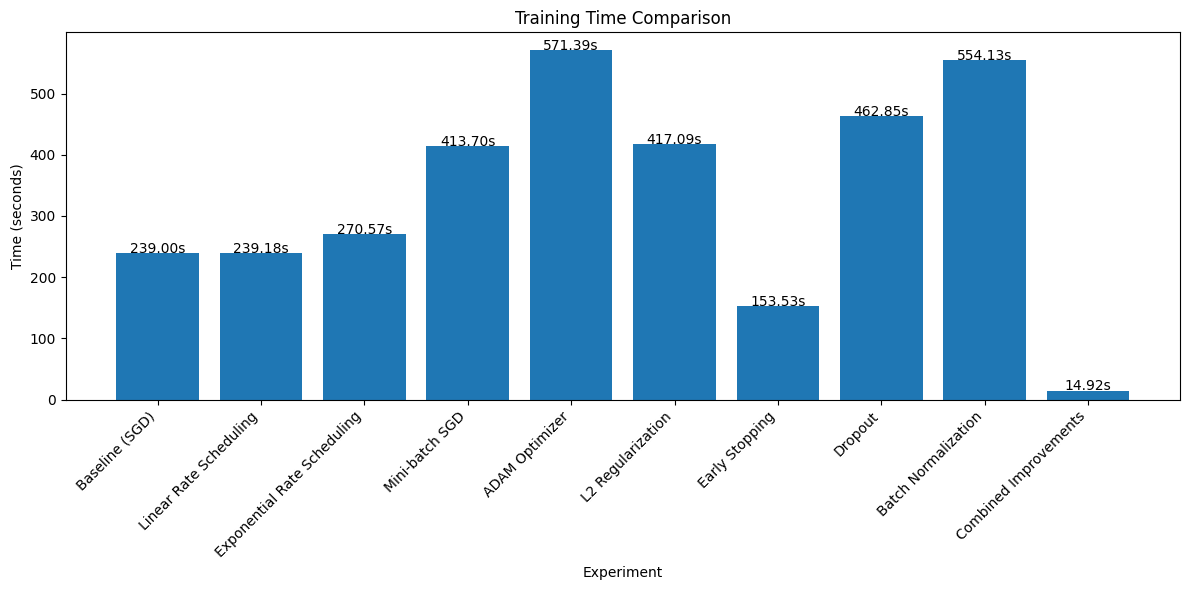

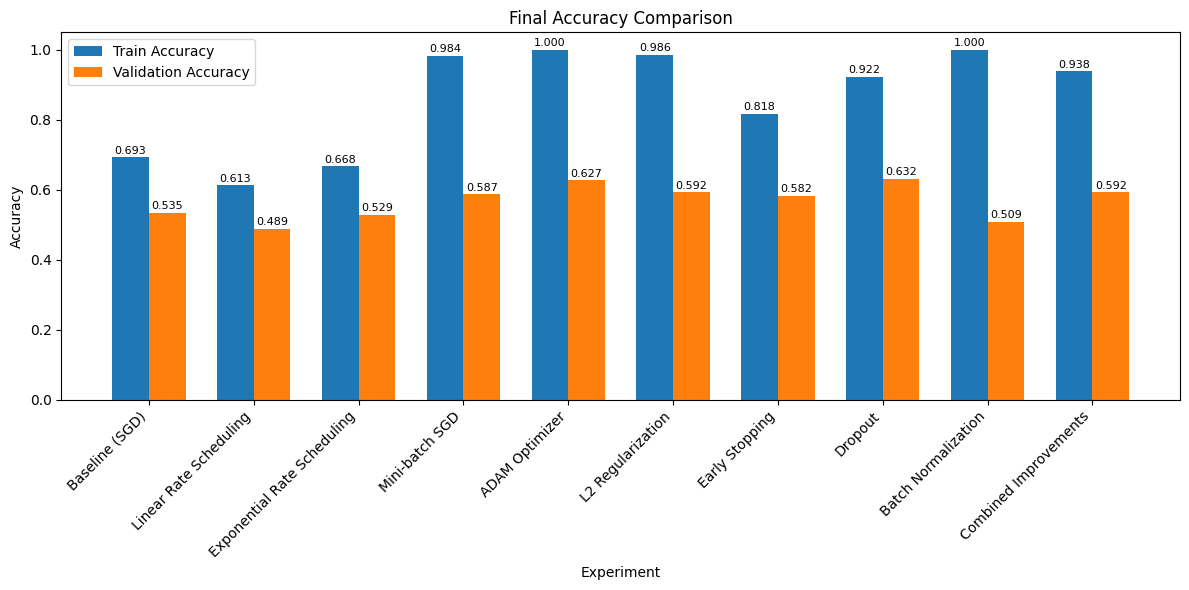

In [15]:
compare_training_times(results)
compare_final_metrics(results)

In [39]:
sorted_results = sorted(results, key=lambda x: x['final_val_accuracy'], reverse=True)

best_result = sorted_results[0]
print(f"\nBest model: {best_result['name']}")
print(f"Validation accuracy: {best_result['final_val_accuracy']:.4f}")

second_best_result = sorted_results[1]
print(f"\nSecond best model: {second_best_result['name']}")
print(f"Validation accuracy: {second_best_result['final_val_accuracy']:.4f}")


Best model: Dropout
Validation accuracy: 0.6322

Second best model: ADAM Optimizer
Validation accuracy: 0.6272


In [ ]:
print("\nExploring different architectures with the best configuration...")
architectures = [
    {
        'name': 'Single Hidden Layer (200)',
        'layer_sizes': [input_size, 200, output_size]
    },{
        'name': 'Two Hidden Layers (100, 80)',
        'layer_sizes': [input_size, 100, 80, output_size]
    },{
        'name': 'Three Hidden Layers (120, 80, 60)',
        'layer_sizes': [input_size, 120, 80, 60, output_size]
    },{
        'name': 'Wide Network (200, 150)',
        'layer_sizes': [input_size, 200, 150, output_size]
    },{
        'name': 'Deep Network (100, 80, 60, 40)',
        'layer_sizes': [input_size, 100, 80, 60, 40, output_size]
    }
]

architecture_results = run_architecture_experiments(
    architectures=architectures,
    cofiguration=best_result,
    ImprovedNeuralNetwork=ImprovedNeuralNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


Exploring different architectures with the best configuration...

Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.5158 - train_acc: 0.9062 - val_loss: 1.4949 - val_acc: 0.6234 - lr: 0.0010

Training completed in 559.07 seconds
Best epoch: 1996
Final train loss: 0.5158, train accuracy: 0.9062
Final val loss: 1.4949, val accuracy: 0.6234
Best val loss: 1.4946, best val accuracy: 0.6234

Results for Single Hidden Layer (200):
Training time: 559.07 seconds
Final train loss: 0.5158, train accuracy: 0.9062
Final val loss: 1.4949, val accuracy: 0.6234

Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=================================================>] 100% - train_loss: 0.4804 - train_acc: 0.9024 - val_loss: 1.5864 - val_acc: 0.6072 - lr: 0.0010

Training completed in 463.16 seconds
Best epoch: 2000
Final train loss: 0.4804, train accuracy: 0.9024
Final val loss: 1.5864, val accuracy: 0.6072
Best val lo

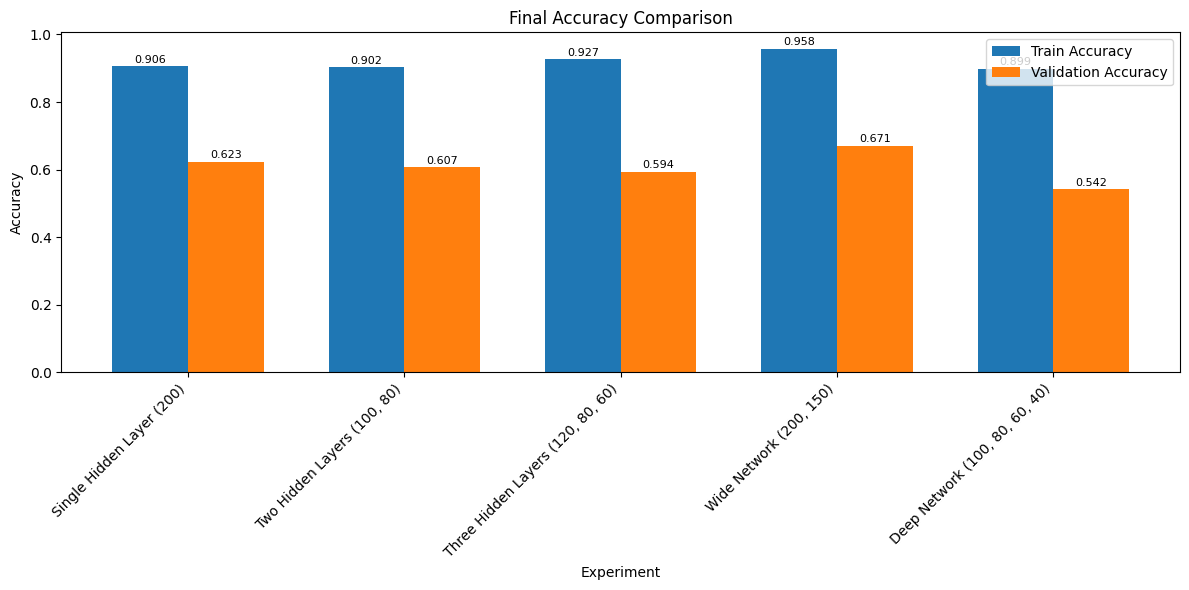


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6708


In [19]:
compare_final_metrics(architecture_results)

best_arch_result = max(architecture_results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result['name']}")
print(f"Validation accuracy: {best_arch_result['final_val_accuracy']:.4f}")

In [38]:
print("\nExploring different architectures with the second best configuration...")

# Get the second best model after the best one
sorted_results = sorted(results, key=lambda x: x['final_val_accuracy'], reverse=True)
second_best_result = sorted_results[1] if len(sorted_results) > 1 else sorted_results[0]

architectures = [
    {
        'name': 'Single Hidden Layer (200)',
        'layer_sizes': [input_size, 200, output_size]
    },{
        'name': 'Two Hidden Layers (100, 80)',
        'layer_sizes': [input_size, 100, 80, output_size]
    },{
        'name': 'Three Hidden Layers (120, 80, 60)',
        'layer_sizes': [input_size, 120, 80, 60, output_size]
    },{
        'name': 'Wide Network (200, 150)',
        'layer_sizes': [input_size, 200, 150, output_size]
    },{
        'name': 'Deep Network (100, 80, 60, 40)',
        'layer_sizes': [input_size, 100, 80, 60, 40, output_size]
    }
]

architecture_results = run_architecture_experiments(
    architectures=architectures,
    cofiguration=second_best_result,
    ImprovedNeuralNetwork=ImprovedNeuralNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


Exploring different architectures with the second best configuration...

Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 5.1552 - val_acc: 0.6484 - lr: 0.0010

Training completed in 1208.01 seconds
Best epoch: 8
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 5.1552, val accuracy: 0.6484
Best val loss: 1.5341, best val accuracy: 0.6135

Results for Single Hidden Layer (200):
Training time: 1208.01 seconds
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 5.1552, val accuracy: 0.6484

Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 6.4396 - val_acc: 0.6334 - lr: 0.0010

Training completed in 865.93 seconds
Best epoch: 10
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 6.4396, val accuracy: 0.6334
Best va

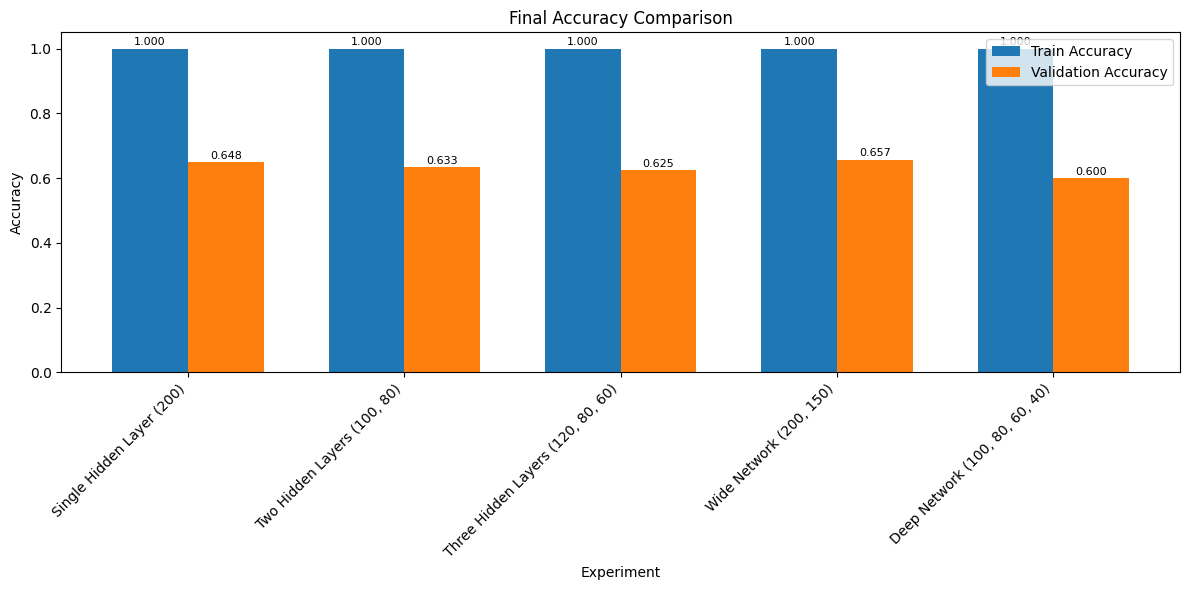


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6571


In [40]:
compare_final_metrics(architecture_results)

best_arch_result = max(architecture_results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result['name']}")
print(f"Validation accuracy: {best_arch_result['final_val_accuracy']:.4f}")

In [42]:
learning_rates_to_test = [0.001, 0.0005, 0.002]

lr_tuning_experiments = []

config = {
        'learning_rate': 0.001,
        'l2_lambda': 0.0,  
        'dropout_rate': 0.2,  
        'use_batch_norm': False,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': 'exponential', 
        'early_stopping_patience': 15 
    }

for lr_value in learning_rates_to_test:
    lr_tuning_experiments.append(config.copy())
    lr_tuning_experiments[-1]['learning_rate'] = lr_value
    lr_tuning_experiments[-1]['name'] = f"LR_{lr_value}"

lr_tuning_results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, best_arch_result['layer_sizes'], lr_tuning_experiments)


Running experiment: LR_0.001
Epoch: [>                                                 ] 0% - train_loss: 0.0226 - train_acc: 1.0000 - val_loss: 1.5309 - val_acc: 0.6721 - lr: 0.0010
Early stopping triggered at epoch 31


Training completed in 29.80 seconds
Best epoch: 16
Final train loss: 0.0226, train accuracy: 1.0000
Final val loss: 1.5309, val accuracy: 0.6721
Best val loss: 1.3789, best val accuracy: 0.6646

Results for LR_0.001:
Training time: 29.80 seconds
Final train loss: 0.1708, train accuracy: 0.9737
Final val loss: 1.3789, val accuracy: 0.6646

Running experiment: LR_0.0005
Epoch: [>                                                 ] 0% - train_loss: 0.1064 - train_acc: 0.9894 - val_loss: 1.4737 - val_acc: 0.6571 - lr: 0.0005
Early stopping triggered at epoch 34


Training completed in 33.57 seconds
Best epoch: 19
Final train loss: 0.1064, train accuracy: 0.9894
Final val loss: 1.4737, val accuracy: 0.6571
Best val loss: 1.4447, best val accuracy: 0.6334

Results for LR_0.0


Graficando resultados del ajuste de LR (sin dropout / l2)...


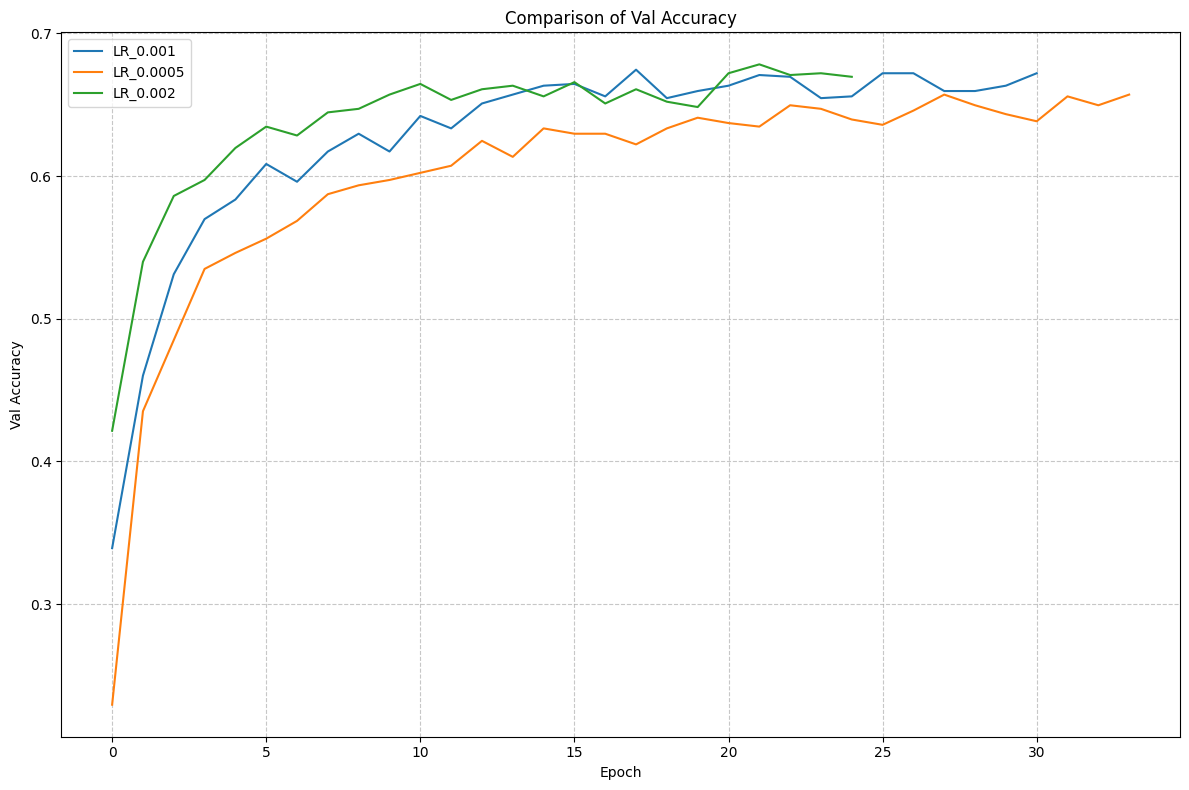

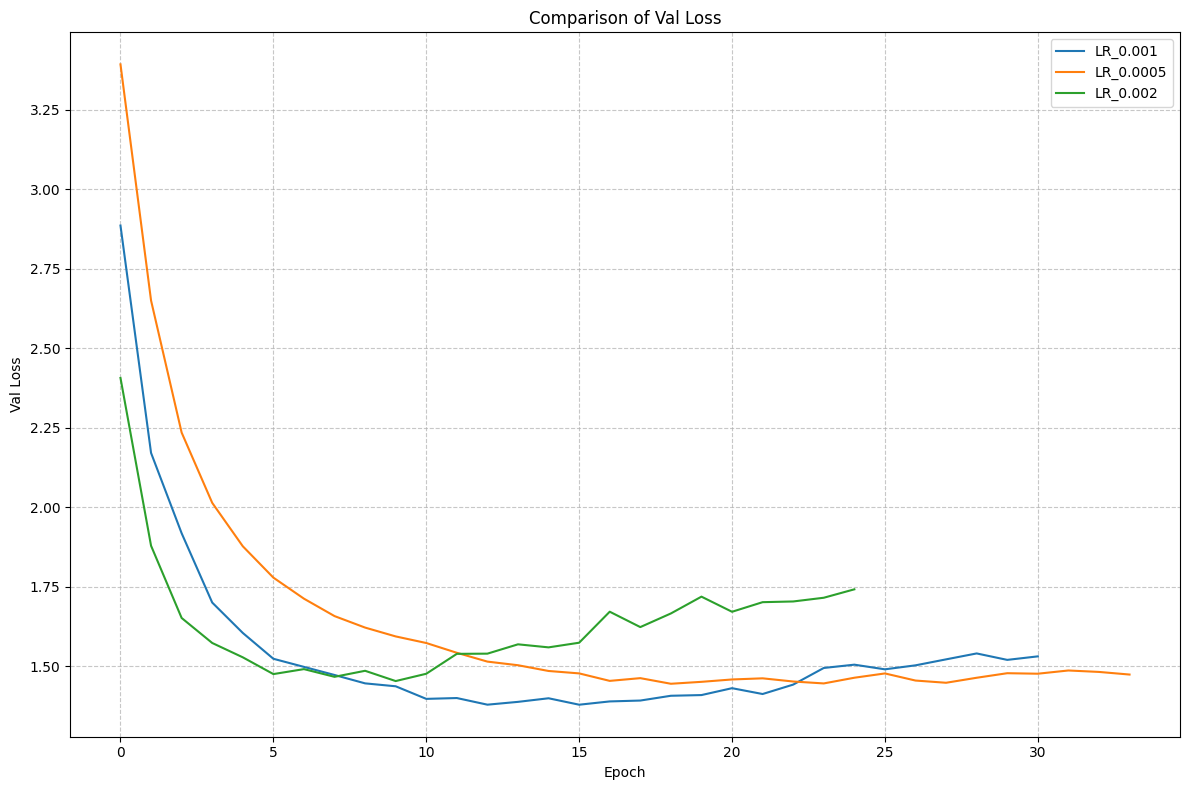

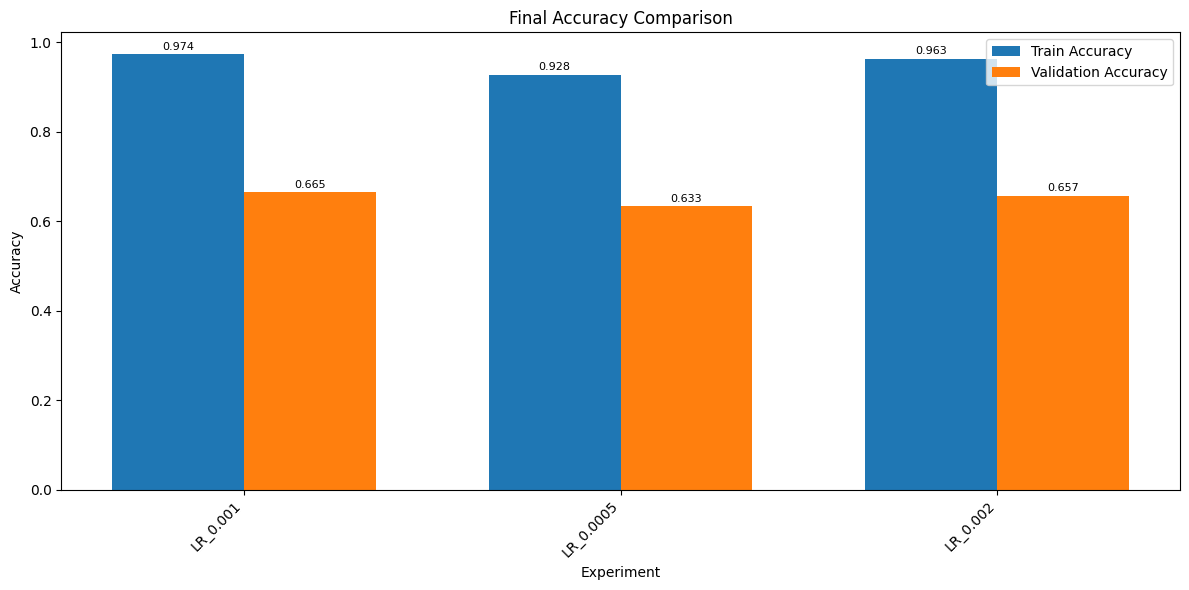


--- Mejor Modelo Después del Ajuste de Tasa de Aprendizaje (sin dropout/l2) ---
Nombre: LR_0.001
Precisión de Validación: 0.6646
Tasa de Aprendizaje: 0.001
Configuración Completa:
  learning_rate: 0.001
  l2_lambda: 0.0
  dropout_rate: 0.2
  use_batch_norm: False
  epochs: 4000
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential
  early_stopping_patience: 15
  name: LR_0.001
  model: <src.improved_neural_network.ImprovedNeuralNetwork object at 0x74cca54e19d0>
  final_train_loss: 0.1708368549184121
  final_train_accuracy: 0.9737253675320613
  final_val_loss: 1.3788690315315866
  final_val_accuracy: 0.6645885286783042
  training_time: 29.795682191848755


In [44]:
print("\nGraficando resultados del ajuste de LR (sin dropout / l2)...")
plot_experiment_results(lr_tuning_results, metric='val_accuracy')
plot_experiment_results(lr_tuning_results, metric='val_loss')
compare_final_metrics(lr_tuning_results)

best_lr_tuned_model = max(lr_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Tasa de Aprendizaje (sin dropout/l2) ---")
print(f"Nombre: {best_lr_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_lr_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Tasa de Aprendizaje: {best_lr_tuned_model.get('learning_rate', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_lr_tuned_model.items():
    if key not in ['history']:
            print(f"  {key}: {value}")

In [ ]:
l2_values_to_test = [0.0001, 0.001, 0.01]

l2_tuning_experiments = []

best_lr = best_lr_tuned_model['learning_rate']

config['learning_rate']= best_lr

for l2_value in l2_values_to_test:
    l2_tuning_experiments.append(config.copy())
    l2_tuning_experiments[-1]['l2_lambda'] = l2_value
    l2_tuning_experiments[-1]['name'] = f"L2_{l2_value}"

l2_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    l2_tuning_experiments
)

In [ ]:
print("\nGraficando resultados del ajuste de L2...")
plot_experiment_results(l2_tuning_results, metric='val_accuracy', title_suffix=" - Ajuste de L2")
plot_experiment_results(l2_tuning_results, metric='val_loss', title_suffix=" - Ajuste de L2")
compare_final_metrics(l2_tuning_results, title_suffix=" - Ajuste de L2")

best_l2_tuned_model = max(l2_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de L2 ---")
print(f"Nombre: {best_l2_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_l2_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"L2 Lambda: {best_l2_tuned_model.get('l2_lambda', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_l2_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [ ]:
dropout_values_to_test = [0.1, 0.3, 0.5]

dropout_tuning_experiments = []

best_l2 = best_l2_tuned_model['l2_lambda']
config['l2_lambda'] = best_l2

for dropout_value in dropout_values_to_test:
    dropout_tuning_experiments.append(config.copy())
    dropout_tuning_experiments[-1]['dropout_rate'] = dropout_value
    dropout_tuning_experiments[-1]['name'] = f"Dropout_{dropout_value}"

dropout_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    dropout_tuning_experiments
)

In [ ]:
print("\nGraficando resultados del ajuste de Dropout...")
plot_experiment_results(dropout_tuning_results, metric='val_accuracy', title_suffix=" - Ajuste de Dropout")
plot_experiment_results(dropout_tuning_results, metric='val_loss', title_suffix=" - Ajuste de Dropout")
compare_final_metrics(dropout_tuning_results, title_suffix=" - Ajuste de Dropout")

best_dropout_tuned_model = max(dropout_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Dropout ---")
print(f"Nombre: {best_dropout_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_dropout_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Dropout Rate: {best_dropout_tuned_model.get('dropout_rate', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_dropout_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [ ]:
batch_sizes_to_test = [32, 64, 128]
batch_size_tuning_experiments = []

best_lr = 0.001  # <-- actualizá según resultados
best_l2 = 0.0005  # <-- actualizá
best_dropout = 0.2  # <-- actualizá según resultados

config = {
    'learning_rate': best_lr,
    'l2_lambda': best_l2,
    'dropout_rate': best_dropout,
    'use_batch_norm': False,
    'epochs': 4000,
    'batch_size': 64,  # lo reemplazamos en el loop
    'optimizer': 'adam',
    'lr_schedule': 'exponential',
    'early_stopping_patience': 15
}

for bs_value in batch_sizes_to_test:
    batch_size_tuning_experiments.append(config.copy())
    batch_size_tuning_experiments[-1]['batch_size'] = bs_value
    batch_size_tuning_experiments[-1]['name'] = f"BatchSize_{bs_value}"

batch_size_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    batch_size_tuning_experiments
)

In [ ]:

print("\nGraficando resultados del ajuste de Batch Size...")
plot_experiment_results(batch_size_tuning_results, metric='val_accuracy', title_suffix=" - Ajuste de Batch Size")
plot_experiment_results(batch_size_tuning_results, metric='val_loss', title_suffix=" - Ajuste de Batch Size")
compare_final_metrics(batch_size_tuning_results, title_suffix=" - Ajuste de Batch Size")

best_bs_tuned_model = max(batch_size_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de Batch Size ---")
print(f"Nombre: {best_bs_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_bs_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Batch Size: {best_bs_tuned_model.get('batch_size', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_bs_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [ ]:
schedules_to_test = ['exponential', 'linear', None]

schedule_tuning_experiments = []

best_lr = 0.001  # actualizá
best_l2 = 0.0005  # actualizá
best_dropout = 0.2  # actualizá
best_bs = 64  # actualizá

config = {
    'learning_rate': best_lr,
    'l2_lambda': best_l2,
    'dropout_rate': best_dropout,
    'use_batch_norm': False,
    'epochs': 4000,
    'batch_size': best_bs,
    'optimizer': 'adam',
    'lr_schedule': 'exponential',  # lo reemplazamos en el loop
    'early_stopping_patience': 15
}

for sched in schedules_to_test:
    schedule_tuning_experiments.append(config.copy())
    schedule_tuning_experiments[-1]['lr_schedule'] = sched
    schedule_tuning_experiments[-1]['name'] = f"LRSchedule_{sched}"

schedule_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    schedule_tuning_experiments
)

print("\nGraficando resultados del ajuste de LR Schedule...")
plot_experiment_results(schedule_tuning_results, metric='val_accuracy', title_suffix=" - Ajuste de LR Schedule")
plot_experiment_results(schedule_tuning_results, metric='val_loss', title_suffix=" - Ajuste de LR Schedule")
compare_final_metrics(schedule_tuning_results, title_suffix=" - Ajuste de LR Schedule")

best_sched_tuned_model = max(schedule_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))
print(f"\n--- Mejor Modelo Después del Ajuste de LR Schedule ---")
print(f"Nombre: {best_sched_tuned_model.get('name', 'N/A')}")
print(f"Precisión de Validación: {best_sched_tuned_model.get('final_val_accuracy', 'N/A'):.4f}")
print(f"Schedule: {best_sched_tuned_model.get('lr_schedule', 'N/A')}")
print(f"Configuración Completa:")
for key, value in best_sched_tuned_model.items():
    if key not in ['history']:
        print(f"  {key}: {value}")


In [22]:
# Evaluate the best model on the test set
final_model = best_arch_result['model']
y_pred_test = final_model.forward(X_test, training=False)
test_loss = final_model.cross_entropy_loss(y_test, y_pred_test)
test_accuracy = final_model.accuracy(y_test, y_pred_test)

print(f"\nFinal model performance on test set:")
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_accuracy:.4f}")

# Compute and plot confusion matrix for the final model
conf_matrix = final_model.confusion_matrix(y_test, y_pred_test)

# Save this model as M1 (the best architecture with improved training)
model_M1 = final_model
save_model(model_M1, "model_M1.pkl")


Final model performance on test set:
Test loss: 1.5448, test accuracy: 0.6314
Model successfully saved to modelos/model_M1.pkl


### 4. Desarrollo de una Red Neuronal con PyTorch
- Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llmaremos a este modelo M2.
- Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. LLamaremos a este modelo M3.
- Utilizando PyTorch, encontrar una arquitectura (capas ocultas y unidades por
capa) que produzca overfitting. Llamaremos a este modelo M4.
Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
    1. El modelo base de implementación propia (M0).
    2. La mejor arquitectura obtenida con la implementación propia (M1).
    3. Modelo en PyTorch, usando la misma arquiterctura e hiperparámetros que en la implementación propia (M2).
    4. La mejor arquitectura obtenida en PyTorch (M3).
    5. Una arquitectura en PyTorch con sobreajuste (M4).

In [23]:
print("\n4.a) Cargando el modelo base (M0) de implementación propia...")
model_M0 = load_model("model_M0.pkl")

# Evaluamos M0 en test
test_pred_M0 = model_M0.forward(X_test)  # Forward pass to get predictions
test_loss_M0 = model_M0.cross_entropy_loss(y_test, test_pred_M0)  # Calculate loss
test_acc_M0 = model_M0.accuracy(y_test, test_pred_M0)  # Calculate accuracy
print(f"Modelo M0 en test: Accuracy={test_acc_M0:.4f}, Loss={test_loss_M0:.4f}")


4.a) Cargando el modelo base (M0) de implementación propia...
Model successfully loaded from modelos/model_M0.pkl
Modelo M0 en test: Accuracy=0.5814, Loss=1.8024


In [24]:
print("\n4.b) Cargando la mejor arquitectura de implementación propia (M1)...")
model_M1 = load_model("model_M1.pkl")

# Evaluamos M1 en test
test_pred_M1 = model_M1.forward(X_test)  # Forward pass to get predictions
test_loss_M1 = model_M1.cross_entropy_loss(y_test, test_pred_M1)  # Calculate loss
test_acc_M1 = model_M1.accuracy(y_test, test_pred_M1)  # Calculate accuracy
print(f"Modelo M1 en test: Accuracy={test_acc_M1:.4f}, Loss={test_loss_M1:.4f}")


4.b) Cargando la mejor arquitectura de implementación propia (M1)...
Model successfully loaded from modelos/model_M1.pkl
Modelo M1 en test: Accuracy=0.5485, Loss=1.9287


In [25]:
print("\n4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...")
model_M2 = PyTorchNetwork(
    layer_sizes=layer_sizes,
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2
)

# Entrenar modelo M2
print("Entrenando modelo M2...")
history_M2 = model_M2.train_model(
    X_train, y_train, X_val, y_val,
    epochs=1000, batch_size=64,
    early_stopping_patience=10,
    verbose=1
)

# Evaluamos M2 en test
test_acc_M2, test_loss_M2, test_pred_M2 = model_M2.evaluate(X_test, y_test)
print(f"Modelo M2 en test: Accuracy={test_acc_M2:.4f}, Loss={test_loss_M2:.4f}")


4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...
Entrenando modelo M2...
Epoch: [=>                                                ] 3% - train_loss: 0.6115 - train_acc: 0.8173 - val_loss: 1.5495 - val_acc: 0.6259
Early stopping triggered at epoch 35


Training completed in 5.16 seconds
Final train loss: 0.6115, train accuracy: 0.8173
Final val loss: 1.5495, val accuracy: 0.6259
Best epoch: 25
Best val loss: 1.5215, best val accuracy: 0.6172
Modelo M2 en test: Accuracy=0.6074, Loss=1.6819


In [26]:
print("\n4.d) Explorando diferentes arquitecturas con PyTorch...")

# Definir diferentes arquitecturas para probar
architectures = [
    {'name': 'One Hidden Layer (200)', 'layers': [input_size, 200, output_size]},
    {'name': 'Two Hidden Layers (100, 80)', 'layers': [input_size, 100, 80, output_size]},
    {'name': 'Three Hidden Layers (120, 80, 60)', 'layers': [input_size, 120, 80, 60, output_size]},
    {'name': 'Wide Network (200, 150)', 'layers': [input_size, 200, 150, output_size]},
    {'name': 'Deep Network (100, 80, 60, 40)', 'layers': [input_size, 100, 80, 60, 40, output_size]}
]

# Entrenar cada arquitectura y guardar resultados
architecture_results = []

for arch in architectures:
    print(f"\nEntrenando {arch['name']}...")
    
    # Inicializar modelo
    model = PyTorchNetwork(
        layer_sizes=arch['layers'],
        learning_rate=0.001,
        l2_lambda=0.0005,
        dropout_rate=0.2
    )
    
    # Entrenar modelo
    history = model.train_model(
        X_train, y_train, X_val, y_val,
        epochs=50, batch_size=64,
        early_stopping_patience=10,
        verbose=1
    )
    
    # Evaluar en el conjunto de test
    test_acc, test_loss, _ = model.evaluate(X_test, y_test)
    
    # Guardar resultados
    arch_result = arch.copy()
    arch_result.update({
        'model': model,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    })
    
    architecture_results.append(arch_result)
    print(f"Arquitectura {arch['name']} en test: Accuracy={test_acc:.4f}, Loss={test_loss:.4f}")

# Encontrar la mejor arquitectura
best_arch = max(architecture_results, key=lambda x: x['test_accuracy'])
print(f"\nMejor arquitectura: {best_arch['name']}")
print(f"Test accuracy: {best_arch['test_accuracy']:.4f}")

# Guardar como modelo M3
model_M3 = best_arch['model']
test_acc_M3 = best_arch['test_accuracy']
test_loss_M3 = best_arch['test_loss']



4.d) Explorando diferentes arquitecturas con PyTorch...

Entrenando One Hidden Layer (200)...
Epoch: [=================================>                ] 68% - train_loss: 0.2324 - train_acc: 0.9603 - val_loss: 1.4975 - val_acc: 0.6471
Early stopping triggered at epoch 34


Training completed in 5.57 seconds
Final train loss: 0.2324, train accuracy: 0.9603
Final val loss: 1.4975, val accuracy: 0.6471
Best epoch: 24
Best val loss: 1.4593, best val accuracy: 0.6484
Arquitectura One Hidden Layer (200) en test: Accuracy=0.6364, Loss=1.6172

Entrenando Two Hidden Layers (100, 80)...
Epoch: [=========================================>        ] 84% - train_loss: 0.5424 - train_acc: 0.8442 - val_loss: 1.6178 - val_acc: 0.6234
Early stopping triggered at epoch 42


Training completed in 6.76 seconds
Final train loss: 0.5424, train accuracy: 0.8442
Final val loss: 1.6178, val accuracy: 0.6234
Best epoch: 32
Best val loss: 1.5376, best val accuracy: 0.6259
Arquitectura Two Hidden Layers (100, 80)

In [27]:
# 4.e) Encontrar una arquitectura con overfitting
print("\n4.e) Implementando arquitectura con overfitting...")

# Configuración para overfit (red más grande, sin regularización)
model_M4 = PyTorchNetwork(
    layer_sizes=[input_size, 300, 200, 150, output_size],
    learning_rate=0.001,
    l2_lambda=0.0,  # Sin regularización
    dropout_rate=0.0  # Sin dropout
)

# Entrenar el modelo (más épocas, sin early stopping)
print("Entrenando modelo M4 (overfitting)...")
history_M4 = model_M4.train_model(
    X_train, y_train, X_val, y_val,
    epochs=2000, batch_size=64,
    early_stopping_patience=None,  # Sin early stopping
    verbose=1
)

# Evaluamos M4 en train y test para verificar overfitting
train_acc_M4, train_loss_M4, _ = model_M4.evaluate(X_train, y_train)
test_acc_M4, test_loss_M4, test_pred_M4 = model_M4.evaluate(X_test, y_test)

print(f"Modelo M4 (overfitting) en train: Accuracy={train_acc_M4:.4f}, Loss={train_loss_M4:.4f}")
print(f"Modelo M4 (overfitting) en test: Accuracy={test_acc_M4:.4f}, Loss={test_loss_M4:.4f}")
print(f"Diferencia entre train y test accuracy: {train_acc_M4 - test_acc_M4:.4f}")


4.e) Implementando arquitectura con overfitting...
Entrenando modelo M4 (overfitting)...
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 8.5835 - val_acc: 0.6509

Training completed in 540.87 seconds
Final train loss: 0.0000, train accuracy: 1.0000
Final val loss: 8.5835, val accuracy: 0.6509
Best epoch: 8
Best val loss: 1.5993, best val accuracy: 0.6022
Modelo M4 (overfitting) en train: Accuracy=1.0000, Loss=0.0000
Modelo M4 (overfitting) en test: Accuracy=0.6314, Loss=9.0167
Diferencia entre train y test accuracy: 0.3686


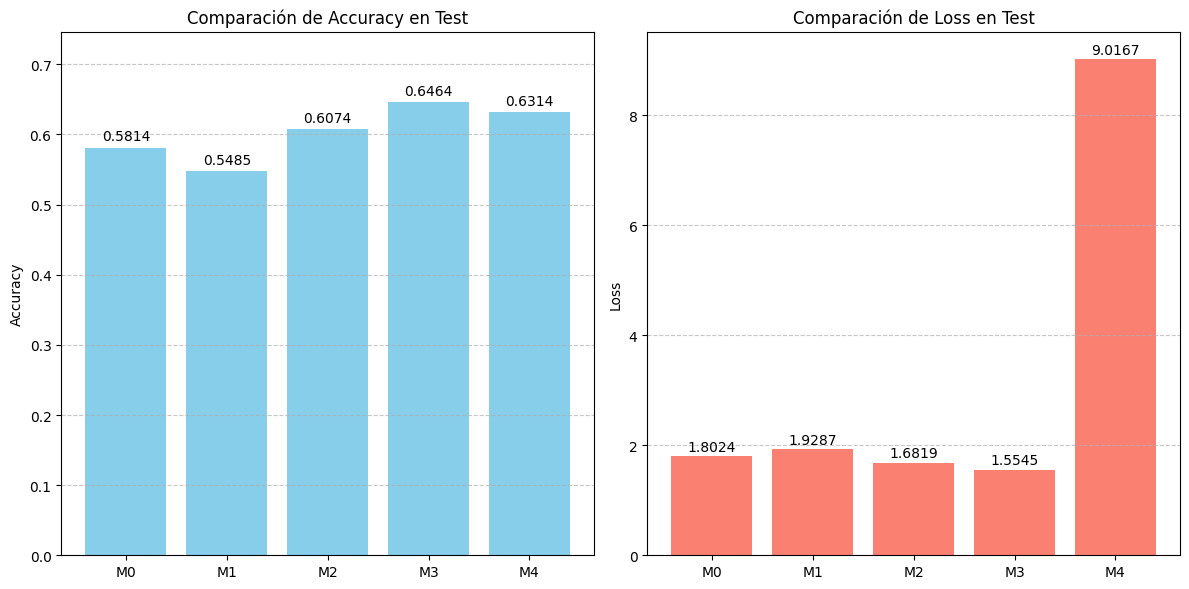


Tabla comparativa de modelos:
Modelo Descripción                              Test Accuracy   Test Loss      
--------------------------------------------------------------------------------
M0    Modelo base implementación propia        0.5814          1.8024         
M1    Mejor modelo implementación propia       0.5485          1.9287         
M2    PyTorch misma arquitectura que M1        0.6074          1.6819         
M3    Mejor arquitectura PyTorch (Wide Network (200, 150)) 0.6464          1.5545         
M4    PyTorch con overfitting                  0.6314          9.0167         

El mejor modelo global es: M3 - Mejor arquitectura PyTorch (Wide Network (200, 150))
Test accuracy: 0.6464


In [28]:
# Comparación de todos los modelos
models_comparison = {
    'M0': {'name': 'Modelo base implementación propia', 'test_acc': test_acc_M0, 'test_loss': test_loss_M0},
    'M1': {'name': 'Mejor modelo implementación propia', 'test_acc': test_acc_M1, 'test_loss': test_loss_M1},
    'M2': {'name': 'PyTorch misma arquitectura que M1', 'test_acc': test_acc_M2, 'test_loss': test_loss_M2},
    'M3': {'name': f'Mejor arquitectura PyTorch ({best_arch["name"]})', 'test_acc': test_acc_M3, 'test_loss': test_loss_M3},
    'M4': {'name': 'PyTorch con overfitting', 'test_acc': test_acc_M4, 'test_loss': test_loss_M4}
}

# Visualizar comparación de modelos
plt.figure(figsize=(12, 6))
models = list(models_comparison.keys())
accuracies = [models_comparison[m]['test_acc'] for m in models]
losses = [models_comparison[m]['test_loss'] for m in models]

# Gráfico de accuracy
plt.subplot(1, 2, 1)
bars = plt.bar(models, accuracies, color='skyblue')

# Añadir los valores encima de las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Accuracy en Test')
plt.ylabel('Accuracy')
plt.ylim(0, max(accuracies) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico de loss
plt.subplot(1, 2, 2)
bars = plt.bar(models, losses, color='salmon')

# Añadir los valores encima de las barras
for bar, loss in zip(bars, losses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{loss:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Loss en Test')
plt.ylabel('Loss')
plt.ylim(0, max(losses) + 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mostrar tabla comparativa
print("\nTabla comparativa de modelos:")
print("=" * 80)
print(f"{'Modelo':<5} {'Descripción':<40} {'Test Accuracy':<15} {'Test Loss':<15}")
print("-" * 80)
for model_id, model_info in models_comparison.items():
    print(f"{model_id:<5} {model_info['name']:<40} {model_info['test_acc']:<15.4f} {model_info['test_loss']:<15.4f}")
print("=" * 80)

# Identificar el mejor modelo general
best_model_id = max(models_comparison.keys(), key=lambda m: models_comparison[m]['test_acc'])
print(f"\nEl mejor modelo global es: {best_model_id} - {models_comparison[best_model_id]['name']}")
print(f"Test accuracy: {models_comparison[best_model_id]['test_acc']:.4f}")

In [29]:
save_model(model_M2, "model_M2.pkl")
save_model(model_M3, "model_M3.pkl")
save_model(model_M4, "model_M4.pkl")

Model successfully saved to modelos/model_M2.pkl
Model successfully saved to modelos/model_M3.pkl
Model successfully saved to modelos/model_M4.pkl


### 5. Desafío
- Utilizando el modelo que considere que sea el mejor, predecir las probabilidades a-posteriori de cada clase del dataset X_COMP.npy y generar un archivo .csv con las predicciones llamado Apellido_Nombre_predicciones.csv. El archivo predicciones.csv debe tener una fila por muestra y las columnas deben ser las probabilidades a posteriori de cada clase.

In [30]:
from src.challenge import run_challenge

run_challenge(model_M3, X_train, y_train)

print("\nComparando predicciones de diferentes modelos:")

# Cargar los datos de competición
X_COMP = np.load("data/X_COMP.npy")
X_COMP = X_COMP / 255.0

# Función para obtener probabilidades según el tipo de modelo
def get_predictions(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)
    elif isinstance(model, torch.nn.Module):
        X_tensor = torch.FloatTensor(X)
        model.eval()
        with torch.no_grad():
            outputs = model(X_tensor)
            return torch.nn.functional.softmax(outputs, dim=1).numpy()
    else:
        raise TypeError("Modelo no soportado")
    
# Cargar los modelos
model_M0 = load_model("model_M0.pkl")
# model_M1 = load_model("model_M1.pkl")
model_M2 = load_model("model_M2.pkl")
model_M3 = load_model("model_M3.pkl")
model_M4 = load_model("model_M4.pkl")

# Comparar distribuciones de probabilidades de diferentes modelos
models_to_compare = {
    'M0': model_M0,
    # 'M1': model_M1,
    'M2': model_M2,
    'M3': model_M3,
    'M4': model_M4
}

# Para visualizar las primeras muestras, tomamos un subconjunto
num_samples = 5
num_classes_to_show = 5

# Para cada modelo, obtener predicciones
for model_name, model in models_to_compare.items():
    print(f"\nPredicciones del modelo {model_name}:")
    probs = model.forward(X_COMP)
    
    # Para las primeras muestras, mostrar las probabilidades más altas
    for i in range(min(num_samples, len(X_COMP))):
        top_classes = np.argsort(-probs[i])[:num_classes_to_show]
        print(f"  Muestra {i}: ", end="")
        for cls in top_classes:
            print(f"Clase_{cls}: {probs[i, cls]:.4f} ", end="")
        print()

# Calcular la correlación entre las predicciones de los modelos
print("\nCorrelación entre predicciones de diferentes modelos:")
model_probs = {}
for model_name, model in models_to_compare.items():
    model_probs[model_name] = model.forward(X_COMP)

correlation_data = {}
for model1 in models_to_compare.keys():
    for model2 in models_to_compare.keys():
        if model1 >= model2:
            continue
        
        # Calcular la correlación entre las decisiones de los modelos
        pred1 = np.argmax(model_probs[model1], axis=1)
        pred2 = np.argmax(model_probs[model2], axis=1)
        agreement = np.mean(pred1 == pred2)
        
        correlation_data[f"{model1} vs {model2}"] = agreement

# Mostrar la correlación
for pair, agreement in correlation_data.items():
    print(f"  {pair}: {agreement:.4f} concordancia")

print("\nRecomendación final:")
print(f"Basado en los resultados de validación y test, recomendamos usar el modelo {best_model_id} para las predicciones finales.")

EJERCICIO 5: DESAFÍO
Error: X_COMP.npy file not found. Make sure it's in the current directory.

Comparando predicciones de diferentes modelos:
Model successfully loaded from modelos/model_M0.pkl
Model successfully loaded from modelos/model_M2.pkl
Model successfully loaded from modelos/model_M3.pkl
Model successfully loaded from modelos/model_M4.pkl

Predicciones del modelo M0:
  Muestra 0: Clase_0: 0.3768 Clase_11: 0.2462 Clase_47: 0.0770 Clase_33: 0.0614 Clase_42: 0.0586 
  Muestra 1: Clase_12: 0.2948 Clase_14: 0.1042 Clase_39: 0.1013 Clase_5: 0.0809 Clase_0: 0.0588 
  Muestra 2: Clase_0: 0.1425 Clase_5: 0.1416 Clase_11: 0.0901 Clase_42: 0.0862 Clase_33: 0.0680 
  Muestra 3: Clase_22: 0.5697 Clase_41: 0.1688 Clase_0: 0.1057 Clase_24: 0.0489 Clase_44: 0.0456 
  Muestra 4: Clase_0: 0.3325 Clase_9: 0.2667 Clase_44: 0.0722 Clase_22: 0.0485 Clase_31: 0.0398 

Predicciones del modelo M2:


TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray